# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance_groupby, compute_variance

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

# Generate

In [2]:
dt=3
distance_to_coast_max = 20e3
alti_product_key='swot2km'


In [4]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km'}),
    update_dict(base_dic, {'alti_product_key':'swot2km', 'ggd_var':'fromduacsv_unfiltered'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

l = [
    'L3-250m-xr-etac',
    'L3-250m-xr-etaf',
    'L3-250m-stencil-etac',
    'L3-250m-stencil-etaf',
    'L3-250m-duacsv',
    'L3-2km-xr-etac',
    'L3-2km-xr-etaf',
    'L3-2km-stencil-etac',
    'L3-2km-stencil-etaf',
    'L3-2km-duacsv',
    'L3-2km-duacsv_unfiltered',
    'L4-no-SWOT-regional-duacsv',
    'L4-no-SWOT-global-duacsv',
    'L4-SWOT-nadir-duacsv']


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb = 0)
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot250m',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')
comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'xarray_diff', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km', 'ggd_var':'fromduacsv_unfiltered'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb = 0)
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

357737
12h_spectral_decomp_all_med_variational_10min_v1____swot250m_xarray_diff__etac__era5_rio0
356146
12h_spectral_decomp_all_med_variational_10min_v1____swot250m_xarray_diff__etaf__era5_rio0
350277
12h_spectral_decomp_all_med_variational_10min_v1____swot250m_diff_only__etac__era5_rio0



KeyboardInterrupt



In [3]:
DS  = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'alticomp_id_comb_row_number.nc'))

In [ ]:
DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')
#DS = DS.where((abs(DS.ggde)<1e-4) & (abs(DS.ggdn)<1e-4), drop=True)
DS = DS.where(DS.distance_to_coast>distance_to_coast_max, drop=True)

DS.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'alticomp_id_comb_row_number.nc'))
    
ds = compute_variance(DS, compute_error = 'bootstrap')/U2

# Closure figs
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')
ds.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))

In [4]:
ds = compute_variance(DS, compute_error = 'centrallimit')/U2

# Closure figs
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')
ds.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.scheduler.transition-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/dask/config.py:742: FutureWarning: Dask configuration key 'distributed.comm.recent-messages-log-length' has been deprecated; please use 'distributed.admin.low-level-log-length' instead
  warnings.warn(


In [5]:
ds.to_netcdf(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))

In [6]:
ds = xr.open_dataset(os.path.join(zarr_dir, 'diag_files', f'alticomp.nc'))
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')

In [12]:
df

,row_number,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,...,E_ggd,E_wd,X_acc_cor,X_acc_ggd,X_acc_wd,X_cor_ggd,X_cor_wd,X_ggd_wd,D_cyclo,D_anticyclo
Altimetric product,,,,,,,,,,,,,,,,,,,,,
L3-250m-xr-etac,55,2023-03-28 21:40:00,5.604628,42.936059,3.0,0 days 02:40:02.155782592,474.0,0-4388554,CARTHE,0.0,...,1227.055432,-7.652194,1.220872,-24.986136,0.182400,75.075454,-0.760936,15.998677,50.089318,76.296326
L3-250m-xr-etac,56,2023-03-28 21:50:00,5.603344,42.936035,3.0,0 days 02:30:02.155782592,474.0,0-4388554,CARTHE,0.0,...,771.729281,-6.243261,1.013140,-14.678999,0.133669,69.734943,-0.748588,13.216031,55.055944,70.748083
L3-250m-xr-etac,58,2023-03-28 22:10:00,5.600761,42.936003,3.0,0 days 02:10:02.155782592,474.0,0-4388554,CARTHE,0.0,...,707.886707,-5.187865,0.530304,-6.742061,0.030508,110.164560,-0.725189,11.185554,103.422499,110.694865
L3-250m-xr-etac,59,2023-03-28 22:20:00,5.599469,42.935989,3.0,0 days 02:00:02.155782592,474.0,0-4388554,CARTHE,0.0,...,1259.465000,-4.196618,0.265679,-7.400203,-0.022563,141.373627,-0.714706,9.247414,133.973424,141.639306
L3-250m-xr-etac,60,2023-03-28 22:30:00,5.598180,42.935973,3.0,0 days 01:50:02.155782592,474.0,0-4388554,CARTHE,0.0,...,1150.465401,-1.931857,-0.007426,-7.404360,-0.074218,121.007520,-0.703750,4.760489,113.603160,121.000094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L4-SWOT-nadir-duacsv,377300,2023-07-09 21:10:00,1.792221,39.326249,16.0,0 days 02:13:38.131544384,577.0,300534060211000,SVP,15.0,...,0.150388,0.094509,0.536353,-0.298018,-0.227470,0.236820,0.270147,-0.095477,-0.061198,0.773173
L4-SWOT-nadir-duacsv,377301,2023-07-09 21:20:00,1.792554,39.326245,16.0,0 days 02:23:38.131544384,577.0,300534060211000,SVP,15.0,...,0.141584,0.079555,0.460005,-0.279830,-0.185236,0.236196,0.251898,-0.094347,-0.043635,0.696200
L4-SWOT-nadir-duacsv,377302,2023-07-09 21:30:00,1.792894,39.326223,16.0,0 days 02:33:38.131544384,577.0,300534060211000,SVP,15.0,...,0.127150,0.064023,0.376314,-0.248457,-0.142047,0.233785,0.233971,-0.093248,-0.014672,0.610098


# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


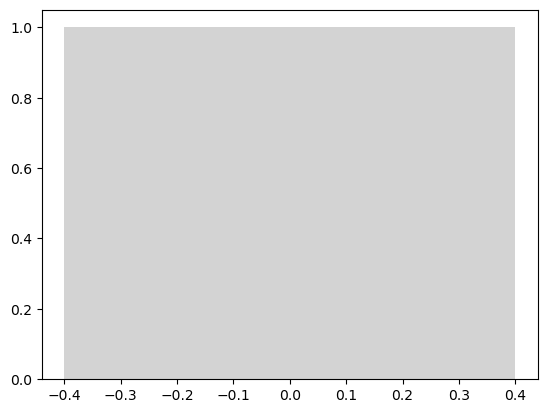

In [6]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


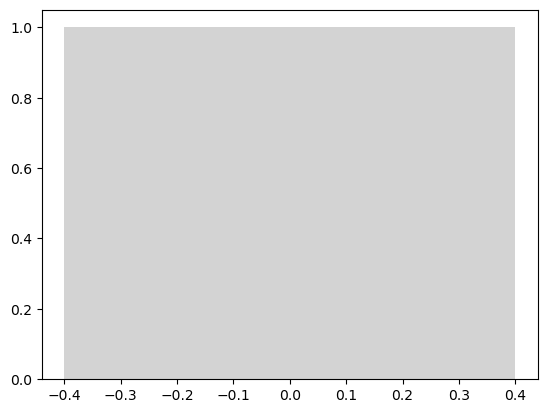

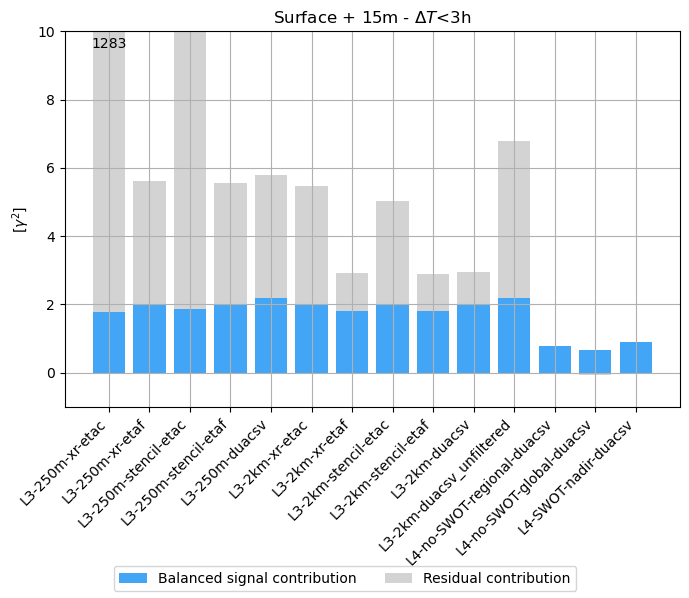

In [7]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45, ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [9]:
DS[['accn', 'ggdn', 'corn', 'wdn']].mean('row_number')/DS[['accn', 'ggdn', 'corn', 'wdn']].std('row_number') 

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 14)
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 112B -0.07116 -0.07116 ... -0.07116 -0.07116
    ggdn     (id_comb) float64 112B -0.02194 -0.1294 ... -0.3937 -0.3272
    corn     (id_comb) float64 112B 0.09842 0.09842 0.09842 ... 0.09842 0.09842
    wdn      (id_comb) float64 112B 0.2 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2 0.2

In [10]:
v=['accn', 'ggdn', 'corn', 'wdn', 'acce', 'ggde', 'core', 'wde']
(DS[v]**2).mean('row_number')/DS[v].var('row_number') 

<xarray.Dataset> Size: 2kB
Dimensions:  (id_comb: 14)
Coordinates:
  * id_comb  (id_comb) <U26 1kB 'L3-250m-xr-etac' ... 'L4-SWOT-nadir-duacsv'
Data variables:
    accn     (id_comb) float64 112B 1.005 1.005 1.005 ... 1.005 1.005 1.005
    ggdn     (id_comb) float64 112B 1.0 1.017 1.001 1.017 ... 1.116 1.155 1.107
    corn     (id_comb) float64 112B 1.01 1.01 1.01 1.01 ... 1.01 1.01 1.01 1.01
    wdn      (id_comb) float64 112B 1.04 1.04 1.04 1.04 ... 1.04 1.04 1.04 1.04
    acce     (id_comb) float64 112B 1.003 1.003 1.003 ... 1.003 1.003 1.003
    ggde     (id_comb) float64 112B 1.0 1.02 1.0 1.02 ... 1.166 1.149 1.134
    core     (id_comb) float64 112B 1.07 1.07 1.07 1.07 ... 1.07 1.07 1.07 1.07
    wde      (id_comb) float64 112B 1.105 1.105 1.105 ... 1.105 1.105 1.105


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x2aaae3425700> (for post_execute):



KeyboardInterrupt



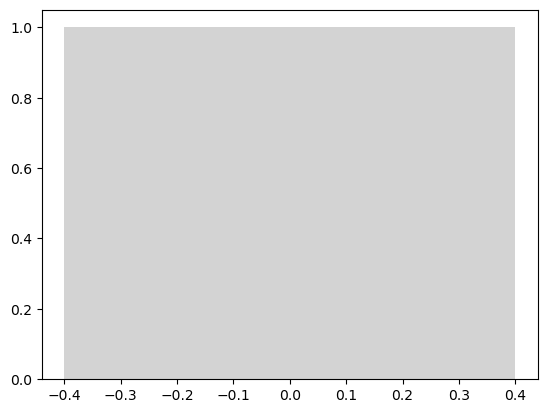

Error in callback <function flush_figures at 0x2aab004884c0> (for post_execute):



KeyboardInterrupt



In [11]:
fig, ax=plt.subplots()
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45,ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1.5,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [ ]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )

axs[2].set_ylim(-1.5,8)
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))


# For papers


In [8]:
df0 = df.copy()

In [9]:
df

,ACCn,CORn,GGDn,WDn,Sn,ACCe,CORe,GGDe,WDe,Se,...,er__E_ggd,er__E_wd,er__X_acc_cor,er__X_acc_ggd,er__X_acc_wd,er__X_cor_ggd,er__X_cor_wd,er__X_ggd_wd,er__D_cyclo,er__D_anticyclo
Altimetric product,,,,,,,,,,,,,,,,,,,,,
L3-250m-xr-etac,1.789839,3.464423,616.591076,0.08923,616.142253,1.751837,3.007131,666.596076,0.403756,667.184325,...,24.966822,0.344048,0.091702,0.853247,0.017724,1.248905,0.042215,0.688150,1.055883,1.251673
L3-250m-xr-etaf,1.789839,3.464423,3.156542,0.08923,2.822025,1.751837,3.007131,2.464860,0.403756,2.513742,...,0.074230,0.016128,0.091702,0.059333,0.017724,0.091538,0.042215,0.021582,0.078355,0.136133
L3-250m-stencil-etac,1.789839,3.464423,465.704355,0.08923,465.131144,1.751837,3.007131,479.055970,0.403756,479.589063,...,18.045957,0.289951,0.091702,0.733496,0.017724,1.066802,0.042215,0.579994,0.899790,1.070354
L3-250m-stencil-etaf,1.789839,3.464423,3.128942,0.08923,2.791975,1.751837,3.007131,2.430734,0.403756,2.479196,...,0.072969,0.015846,0.091702,0.059014,0.017724,0.091111,0.042215,0.020794,0.077948,0.135828
L3-250m-duacsv,1.789839,3.464423,2.939407,0.08923,2.483325,1.751837,3.007131,2.856675,0.403756,2.641836,...,0.076907,0.019668,0.091702,0.059818,0.017724,0.094194,0.042215,0.032169,0.084078,0.138243
L3-2km-xr-etac,1.789839,3.464423,2.967752,0.08923,2.640988,1.751837,3.007131,2.504041,0.403756,2.548206,...,0.048328,0.014762,0.091702,0.057682,0.017724,0.090228,0.042215,0.020281,0.075396,0.136134
L3-2km-xr-etaf,1.789839,3.464423,1.690485,0.08923,1.486046,1.751837,3.007131,1.243387,0.403756,1.506736,...,0.022770,0.013110,0.091702,0.040426,0.017724,0.069101,0.042215,0.011363,0.059153,0.122833
L3-2km-stencil-etac,1.789839,3.464423,2.723724,0.08923,2.409223,1.751837,3.007131,2.311423,0.403756,2.368078,...,0.042659,0.014282,0.091702,0.055100,0.017724,0.087032,0.042215,0.018802,0.072895,0.134048
L3-2km-stencil-etaf,1.789839,3.464423,1.672709,0.08923,1.474592,1.751837,3.007131,1.229777,0.403756,1.497441,...,0.022474,0.013090,0.091702,0.040181,0.017724,0.068658,0.042215,0.011277,0.058784,0.122585


In [10]:
df0 = df0.loc[[
       'L3-250m-stencil-etac', 'L3-250m-stencil-etaf',
    'L3-2km-stencil-etac', 'L3-2km-stencil-etaf', 'L4-SWOT-nadir-duacsv', 'L4-no-SWOT-regional-duacsv',
       'L4-no-SWOT-global-duacsv']]
df0 = df0.reset_index()
df0['Altimetric product'] = ['Calibrated L3-250m', 
                             'Filtered L3-250m',
                             'Calibrated L3-2km', 
                             'Filtered L3-2km', 
                             'L4-SWOT-nadir',
                             'L4-regional',
                             'L4-global', 
                            ]


In [11]:
df0 = df0.set_index('Altimetric product')
#df0 = df.reindex(['Filtered L3-250m', 'Calibrated L3-2km', 'Filtered L3-2km','L4-SWOT-nadir', 'L4-regional', 'L4-global',])

In [13]:
df0.E_ggd

Altimetric product
Calibrated L3-250m    942.898013
Filtered L3-250m        3.573170
Calibrated L3-2km       3.063970
Filtered L3-2km         1.095006
L4-SWOT-nadir          -0.007625
L4-regional             0.005478
L4-global              -0.061401
Name: E_ggd, dtype: float64

In [14]:
df0.B_ggd

Altimetric product
Calibrated L3-250m    1.862312
Filtered L3-250m      1.986506
Calibrated L3-2km     1.971176
Filtered L3-2km       1.807480
L4-SWOT-nadir         0.905826
L4-regional           0.782731
L4-global             0.664021
Name: B_ggd, dtype: float64

In [15]:
df0.E_ggd/df0.GGD

Altimetric product
Calibrated L3-250m    0.998029
Filtered L3-250m      0.642694
Calibrated L3-2km     0.608517
Filtered L3-2km       0.377265
L4-SWOT-nadir        -0.008489
L4-regional           0.006951
L4-global            -0.101891
dtype: float64

In [16]:
df0.B_ggd/df0.B_ggd.loc['Filtered L3-2km']

Altimetric product
Calibrated L3-250m    1.030336
Filtered L3-250m      1.099047
Calibrated L3-2km     1.090566
Filtered L3-2km       1.000000
L4-SWOT-nadir         0.501154
L4-regional           0.433051
L4-global             0.367374
Name: B_ggd, dtype: float64

In [17]:
from diagnosis import sshnoisestd_from_MSnoiseggd
sshnoisestd_from_MSnoiseggd(df0.E_ggd)*1e2

Caution : E_ggd must be given in gamma^2, std must return in m


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Altimetric product
Calibrated L3-250m    8.183396
Filtered L3-250m      0.503765
Calibrated L3-2km     0.466491
Filtered L3-2km       0.278875
L4-SWOT-nadir              NaN
L4-regional           0.019726
L4-global                  NaN
Name: E_ggd, dtype: float64

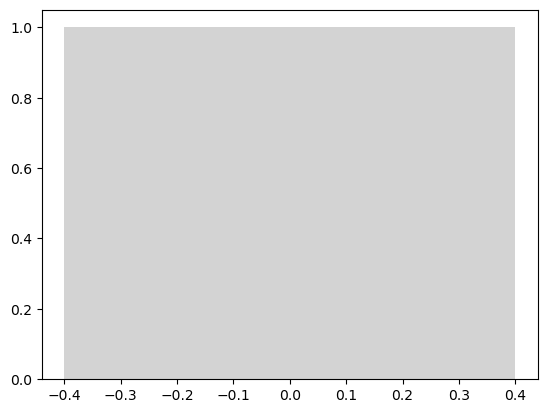

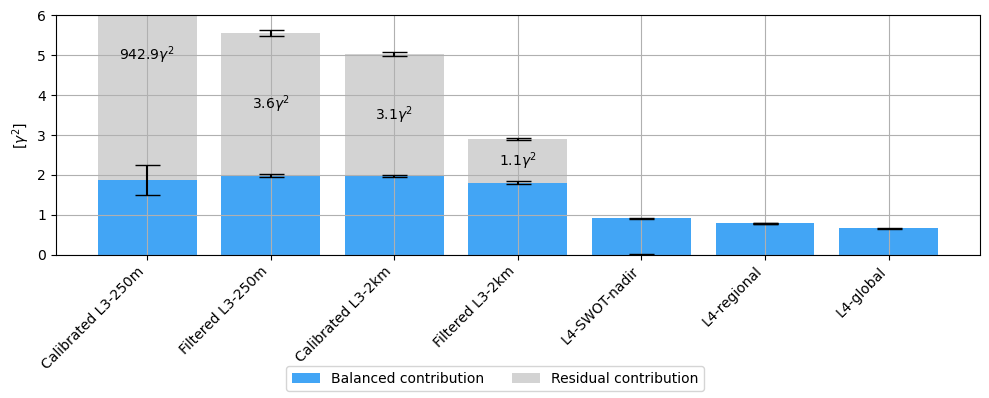

In [26]:
error_kwargs = dict(color="k", capsize=9)

fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(10,4))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df0)):
    df_ = df0.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: 
        ax.bar(i, df_.E_ggd, bottom = df_.B_ggd, color = 'lightgrey')
        ax.errorbar(i, df_.E_ggd + df_.B_ggd, df_.er__E_ggd, **error_kwargs)
    else: 
        ax.bar(i, df_.E_ggd,color = 'lightgrey')
        ax.errorbar(i, df_.E_ggd, df_.er__E_ggd,**error_kwargs)
    ax.bar(i, df_.B_ggd,color = c0['ggd'])
    ax.errorbar(i, df_.B_ggd, df_.er__B_ggd, **error_kwargs)
    if i==0 :
        ax.text(
            i,
            5,
            str(np.round(df_["E_ggd"], 1))+r'$\gamma^2$',
            horizontalalignment="center",
            verticalalignment="center",
        )
    if i in [1, 2, 3]:
        ax.text(
            i,
            df_["B_ggd"]+ df_["E_ggd"]/2,
            str(np.round(df_["E_ggd"], 1))+r'$\gamma^2$',
            horizontalalignment="center",
            verticalalignment="center",
        )

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df0)),labels = df0.index, rotation = 45, ha='right' )
#ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0,6)
#ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [27]:
df.E_ggd/df.GGD*100

Altimetric product
L3-250m-xr-etac               99.861864
L3-250m-xr-etaf               64.687259
L3-250m-stencil-etac          99.802880
L3-250m-stencil-etaf          64.269390
L3-250m-duacsv                62.427834
L3-2km-xr-etac                63.749494
L3-2km-xr-etaf                38.211396
L3-2km-stencil-etac           60.851662
L3-2km-stencil-etaf           37.726486
L3-2km-duacsv                 33.047562
L3-2km-duacsv_unfiltered      67.858522
L4-no-SWOT-regional-duacsv     0.695051
L4-no-SWOT-global-duacsv     -10.189066
L4-SWOT-nadir-duacsv          -0.848943
dtype: float64

# Related SSH RMS 

In [28]:
A = 141464.15110761
def sigmassh(E_ggd) : return np.sqrt(E_ggd/A)

#
sigmassh(df.E_ggd)/1e-2 # cm

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Altimetric product
L3-250m-xr-etac               9.517473
L3-250m-xr-etaf               0.507001
L3-250m-stencil-etac          8.164116
L3-250m-stencil-etaf          0.502578
L3-250m-duacsv                0.505747
L3-2km-xr-etac                0.496569
L3-2km-xr-etaf                0.281510
L3-2km-stencil-etac           0.465392
L3-2km-stencil-etaf           0.278218
L3-2km-duacsv                 0.263027
L3-2km-duacsv_unfiltered      0.570714
L4-no-SWOT-regional-duacsv    0.019679
L4-no-SWOT-global-duacsv           NaN
L4-SWOT-nadir-duacsv               NaN
Name: E_ggd, dtype: float64

In [29]:
# Variance
sigmassh(df.E_ggd)**2/1e-4 # cm^2

Altimetric product
L3-250m-xr-etac               90.582285
L3-250m-xr-etaf                0.257050
L3-250m-stencil-etac          66.652788
L3-250m-stencil-etaf           0.252585
L3-250m-duacsv                 0.255780
L3-2km-xr-etac                 0.246581
L3-2km-xr-etaf                 0.079248
L3-2km-stencil-etac            0.216590
L3-2km-stencil-etaf            0.077405
L3-2km-duacsv                  0.069183
L3-2km-duacsv_unfiltered       0.325715
L4-no-SWOT-regional-duacsv     0.000387
L4-no-SWOT-global-duacsv            NaN
L4-SWOT-nadir-duacsv                NaN
Name: E_ggd, dtype: float64

# Differenciation methods comparisons

In [30]:
df1 = df.copy()
df1 = df1.loc[['L3-250m-duacsv', 'L3-250m-stencil-etaf', 'L3-250m-xr-etaf']]
df1 = df1.reset_index()
df1['Altimetric product'] = ['From duacs velocities', 'Stencil differentiation','Centered differentiation',]
df1 = df1.set_index('Altimetric product')

df2 = df.copy()
df2 = df2.loc[['L3-2km-duacsv', 'L3-2km-stencil-etaf', 'L3-2km-xr-etaf']]
df2 = df2.reset_index()
df2['Altimetric product'] = ['From duacs velocities', 'Stencil differentiation','Centered differentiation',]
df2 = df2.set_index('Altimetric product')

In [ ]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, axs = plt.subplots(1,2, frameon=False, figsize=(10,4))
plt.rcParams["axes.edgecolor"] = "k"

ax = axs[0]
for i in range(len(df1)):
    df_ = df1.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: 
        ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
        ax.errorbar(i, df_.E_ggd+df_.B_ggd, df_.er
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df1)),labels = df1.index, rotation = 45, ha='right' )
#ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0,6)
ax.set_title('Calibrated L3-2km')

ax = axs[1]
for i in range(len(df2)):
    df_ = df2.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df2)),labels = df2.index, rotation = 45, ha='right' )
#ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(0,6)
ax.set_title('Filtered L3-2km')


#ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


In [ ]:
df1